In [1]:
import pandas as pd

df = pd.read_csv('appointments.csv')
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())


(110527, 14)
      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0        0             0      No  
1         0           0  

In [2]:
df.isnull()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,False,False,False,False,False,False,False,False,False,False,False,False,False,False
110523,False,False,False,False,False,False,False,False,False,False,False,False,False,False
110524,False,False,False,False,False,False,False,False,False,False,False,False,False,False
110525,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [3]:
print(df['No-show'].value_counts())
print(df['No-show'].value_counts(normalize=True))


No     88208
Yes    22319
Name: No-show, dtype: int64
No     0.798067
Yes    0.201933
Name: No-show, dtype: float64


In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')
print(df.columns)


Index(['patientid', 'appointmentid', 'gender', 'scheduledday',
       'appointmentday', 'age', 'neighbourhood', 'scholarship', 'hipertension',
       'diabetes', 'alcoholism', 'handcap', 'sms_received', 'no_show'],
      dtype='object')


In [5]:
df['appointment_date'] = pd.to_datetime(df['appointmentday'])
df['scheduled_date'] = pd.to_datetime(df['scheduledday'])


In [6]:
df['waiting_time'] = (df['appointment_date'] - df['scheduled_date']).dt.days
print(df['waiting_time'].describe())


count    110527.000000
mean          9.183702
std          15.254996
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: waiting_time, dtype: float64


In [7]:
print(df[df['waiting_time'] < 0])


           patientid  appointmentid gender          scheduledday  \
0       2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1       5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2       4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3       8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4       8.841186e+12        5642494      F  2016-04-29T16:07:23Z   
...              ...            ...    ...                   ...   
110511  8.235996e+11        5786742      F  2016-06-08T08:50:20Z   
110512  9.876246e+13        5786368      F  2016-06-08T08:20:01Z   
110513  8.674778e+13        5785964      M  2016-06-08T07:52:55Z   
110514  2.695685e+12        5786567      F  2016-06-08T08:35:31Z   
110517  5.574942e+12        5780122      F  2016-06-07T07:38:34Z   

              appointmentday  age      neighbourhood  scholarship  \
0       2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0   
1       2016-04-29T00:00:00Z   56    JARDIM D

In [8]:
df['appointment_weekday'] = df['appointment_date'].dt.day_name()
df['appointment_month'] = df['appointment_date'].dt.month


In [9]:
df['no_show'] = df['no_show'].map({'No':0, 'Yes':1})
print(df['no_show'].value_counts())


0    88208
1    22319
Name: no_show, dtype: int64


In [10]:
df.to_csv('cleaned_no_show.csv', index=False)


In [11]:
print(df['gender'].unique())
print(df['appointment_weekday'].unique())
print(df['neighbourhood'].unique())


['F' 'M']
['Friday' 'Tuesday' 'Monday' 'Wednesday' 'Thursday' 'Saturday']
['JARDIM DA PENHA' 'MATA DA PRAIA' 'PONTAL DE CAMBURI' 'REPÚBLICA'
 'GOIABEIRAS' 'ANDORINHAS' 'CONQUISTA' 'NOVA PALESTINA' 'DA PENHA'
 'TABUAZEIRO' 'BENTO FERREIRA' 'SÃO PEDRO' 'SANTA MARTHA' 'SÃO CRISTÓVÃO'
 'MARUÍPE' 'GRANDE VITÓRIA' 'SÃO BENEDITO' 'ILHA DAS CAIEIRAS'
 'SANTO ANDRÉ' 'SOLON BORGES' 'BONFIM' 'JARDIM CAMBURI' 'MARIA ORTIZ'
 'JABOUR' 'ANTÔNIO HONÓRIO' 'RESISTÊNCIA' 'ILHA DE SANTA MARIA'
 'JUCUTUQUARA' 'MONTE BELO' 'MÁRIO CYPRESTE' 'SANTO ANTÔNIO' 'BELA VISTA'
 'PRAIA DO SUÁ' 'SANTA HELENA' 'ITARARÉ' 'INHANGUETÁ' 'UNIVERSITÁRIO'
 'SÃO JOSÉ' 'REDENÇÃO' 'SANTA CLARA' 'CENTRO' 'PARQUE MOSCOSO'
 'DO MOSCOSO' 'SANTOS DUMONT' 'CARATOÍRA' 'ARIOVALDO FAVALESSA'
 'ILHA DO FRADE' 'GURIGICA' 'JOANA D´ARC' 'CONSOLAÇÃO' 'PRAIA DO CANTO'
 'BOA VISTA' 'MORADA DE CAMBURI' 'SANTA LUÍZA' 'SANTA LÚCIA'
 'BARRO VERMELHO' 'ESTRELINHA' 'FORTE SÃO JOÃO' 'FONTE GRANDE'
 'ENSEADA DO SUÁ' 'SANTOS REIS' 'PIEDADE' 'JESUS DE NA

In [12]:
df['gender'] = df['gender'].map({'F': 0, 'M': 1})


In [13]:
df = pd.get_dummies(df, columns=['neighbourhood', 'appointment_weekday'], drop_first=True)


In [14]:
df = df.drop(['scheduledday', 'appointmentday'], axis=1)
df


,patientid,appointmentid,gender,age,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,...,neighbourhood_SÃO JOSÉ,neighbourhood_SÃO PEDRO,neighbourhood_TABUAZEIRO,neighbourhood_UNIVERSITÁRIO,neighbourhood_VILA RUBIM,appointment_weekday_Monday,appointment_weekday_Saturday,appointment_weekday_Thursday,appointment_weekday_Tuesday,appointment_weekday_Wednesday
0,2.987250e+13,5642903,0,62,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5.589978e+14,5642503,1,56,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4.262962e+12,5642549,0,62,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,8.679512e+11,5642828,0,8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8.841186e+12,5642494,0,56,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,0,56,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
110523,3.596266e+12,5650093,0,51,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
110524,1.557663e+13,5630692,0,21,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
110525,9.213493e+13,5630323,0,38,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [15]:
print(df.columns)



Index(['patientid', 'appointmentid', 'gender', 'age', 'scholarship',
       'hipertension', 'diabetes', 'alcoholism', 'handcap', 'sms_received',
       'no_show', 'appointment_date', 'scheduled_date', 'waiting_time',
       'appointment_month', 'neighbourhood_ANDORINHAS',
       'neighbourhood_ANTÔNIO HONÓRIO', 'neighbourhood_ARIOVALDO FAVALESSA',
       'neighbourhood_BARRO VERMELHO', 'neighbourhood_BELA VISTA',
       'neighbourhood_BENTO FERREIRA', 'neighbourhood_BOA VISTA',
       'neighbourhood_BONFIM', 'neighbourhood_CARATOÍRA',
       'neighbourhood_CENTRO', 'neighbourhood_COMDUSA',
       'neighbourhood_CONQUISTA', 'neighbourhood_CONSOLAÇÃO',
       'neighbourhood_CRUZAMENTO', 'neighbourhood_DA PENHA',
       'neighbourhood_DE LOURDES', 'neighbourhood_DO CABRAL',
       'neighbourhood_DO MOSCOSO', 'neighbourhood_DO QUADRO',
       'neighbourhood_ENSEADA DO SUÁ', 'neighbourhood_ESTRELINHA',
       'neighbourhood_FONTE GRANDE', 'neighbourhood_FORTE SÃO JOÃO',
       'neighbourhoo

In [16]:
X = df.drop('no_show', axis=1)
y = df['no_show']


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [18]:
numeric_cols = ['age', 'waiting_time', 'sms_received']  # only columns that exist


In [19]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'waiting_time', 'sms_received']  # List your numeric columns including the new date-derived features

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [20]:
# Extract features from datetime columns
df['appointment_day'] = df['appointment_date'].dt.day
df['appointment_month'] = df['appointment_date'].dt.month
df['appointment_weekday'] = df['appointment_date'].dt.weekday

df['scheduled_day'] = df['scheduled_date'].dt.day
df['scheduled_month'] = df['scheduled_date'].dt.month
df['scheduled_weekday'] = df['scheduled_date'].dt.weekday

# Drop original datetime columns
df = df.drop(['appointment_date', 'scheduled_date'], axis=1)

# Now check data types to confirm no datetime objects remain
print(df.dtypes)

# Separate features and target (assuming target column is 'no_show')
X = df.drop('no_show', axis=1)
y = df['no_show']

# Optional: select numeric columns only (in case there are categorical still)
numeric_cols = X.select_dtypes(include=['int64', 'float64', 'uint8']).columns

# Scale numeric features if needed
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Then split dataset and train your model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

# Then evaluate model
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


patientid              float64
appointmentid            int64
gender                   int64
age                      int64
scholarship              int64
                        ...   
appointment_day          int64
appointment_weekday      int64
scheduled_day            int64
scheduled_month          int64
scheduled_weekday        int64
Length: 103, dtype: object
[[17507   162]
 [ 4340    97]]
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17669
           1       0.37      0.02      0.04      4437

    accuracy                           0.80     22106
   macro avg       0.59      0.51      0.46     22106
weighted avg       0.72      0.80      0.72     22106



In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


In [22]:
reg = LogisticRegression()

# Fit the model on your training data
reg.fit(X_train, y_train)

# Now you can predict probabilities or classes
y_probs = reg.predict_proba(X_test)[:, 1]


In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7963448837419705


In [24]:
from sklearn.metrics import classification_report

print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.99      0.89     17669
           1       0.37      0.02      0.04      4437

    accuracy                           0.80     22106
   macro avg       0.59      0.51      0.46     22106
weighted avg       0.72      0.80      0.72     22106



In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)
print(f"AUC: {auc_score:.4f}")


AUC: 0.6581


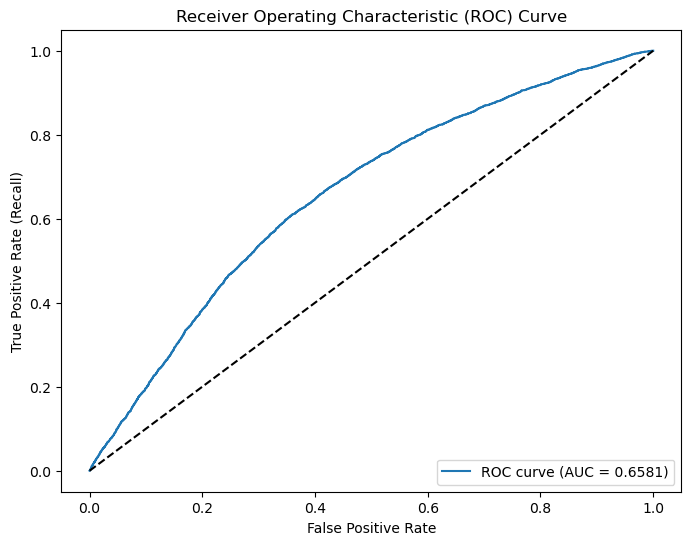

In [26]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guess
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [27]:
df

,patientid,appointmentid,gender,age,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,...,appointment_weekday_Monday,appointment_weekday_Saturday,appointment_weekday_Thursday,appointment_weekday_Tuesday,appointment_weekday_Wednesday,appointment_day,appointment_weekday,scheduled_day,scheduled_month,scheduled_weekday
0,2.987250e+13,5642903,0,62,0,1,0,0,0,0,...,0,0,0,0,0,29,4,29,4,4
1,5.589978e+14,5642503,1,56,0,0,0,0,0,0,...,0,0,0,0,0,29,4,29,4,4
2,4.262962e+12,5642549,0,62,0,0,0,0,0,0,...,0,0,0,0,0,29,4,29,4,4
3,8.679512e+11,5642828,0,8,0,0,0,0,0,0,...,0,0,0,0,0,29,4,29,4,4
4,8.841186e+12,5642494,0,56,0,1,1,0,0,0,...,0,0,0,0,0,29,4,29,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,0,56,0,0,0,0,0,1,...,0,0,0,1,0,7,1,3,5,1
110523,3.596266e+12,5650093,0,51,0,0,0,0,0,1,...,0,0,0,1,0,7,1,3,5,1
110524,1.557663e+13,5630692,0,21,0,0,0,0,0,1,...,0,0,0,1,0,7,1,27,4,2
110525,9.213493e+13,5630323,0,38,0,0,0,0,0,1,...,0,0,0,1,0,7,1,27,4,2


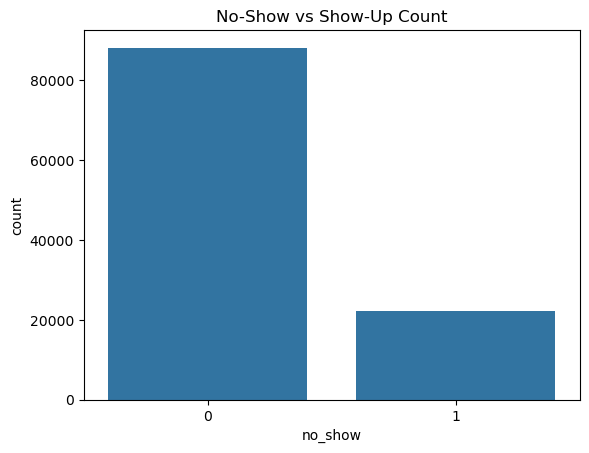

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='no_show', data=df)
plt.title('No-Show vs Show-Up Count')
plt.show()


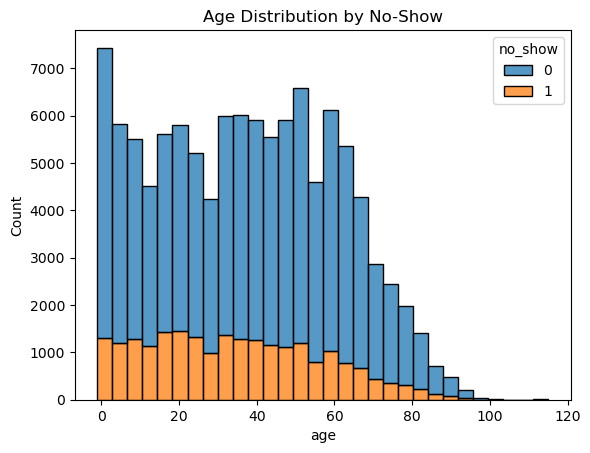

In [29]:
sns.histplot(data=df, x='age', hue='no_show', multiple='stack', bins=30)
plt.title('Age Distribution by No-Show')
plt.show()


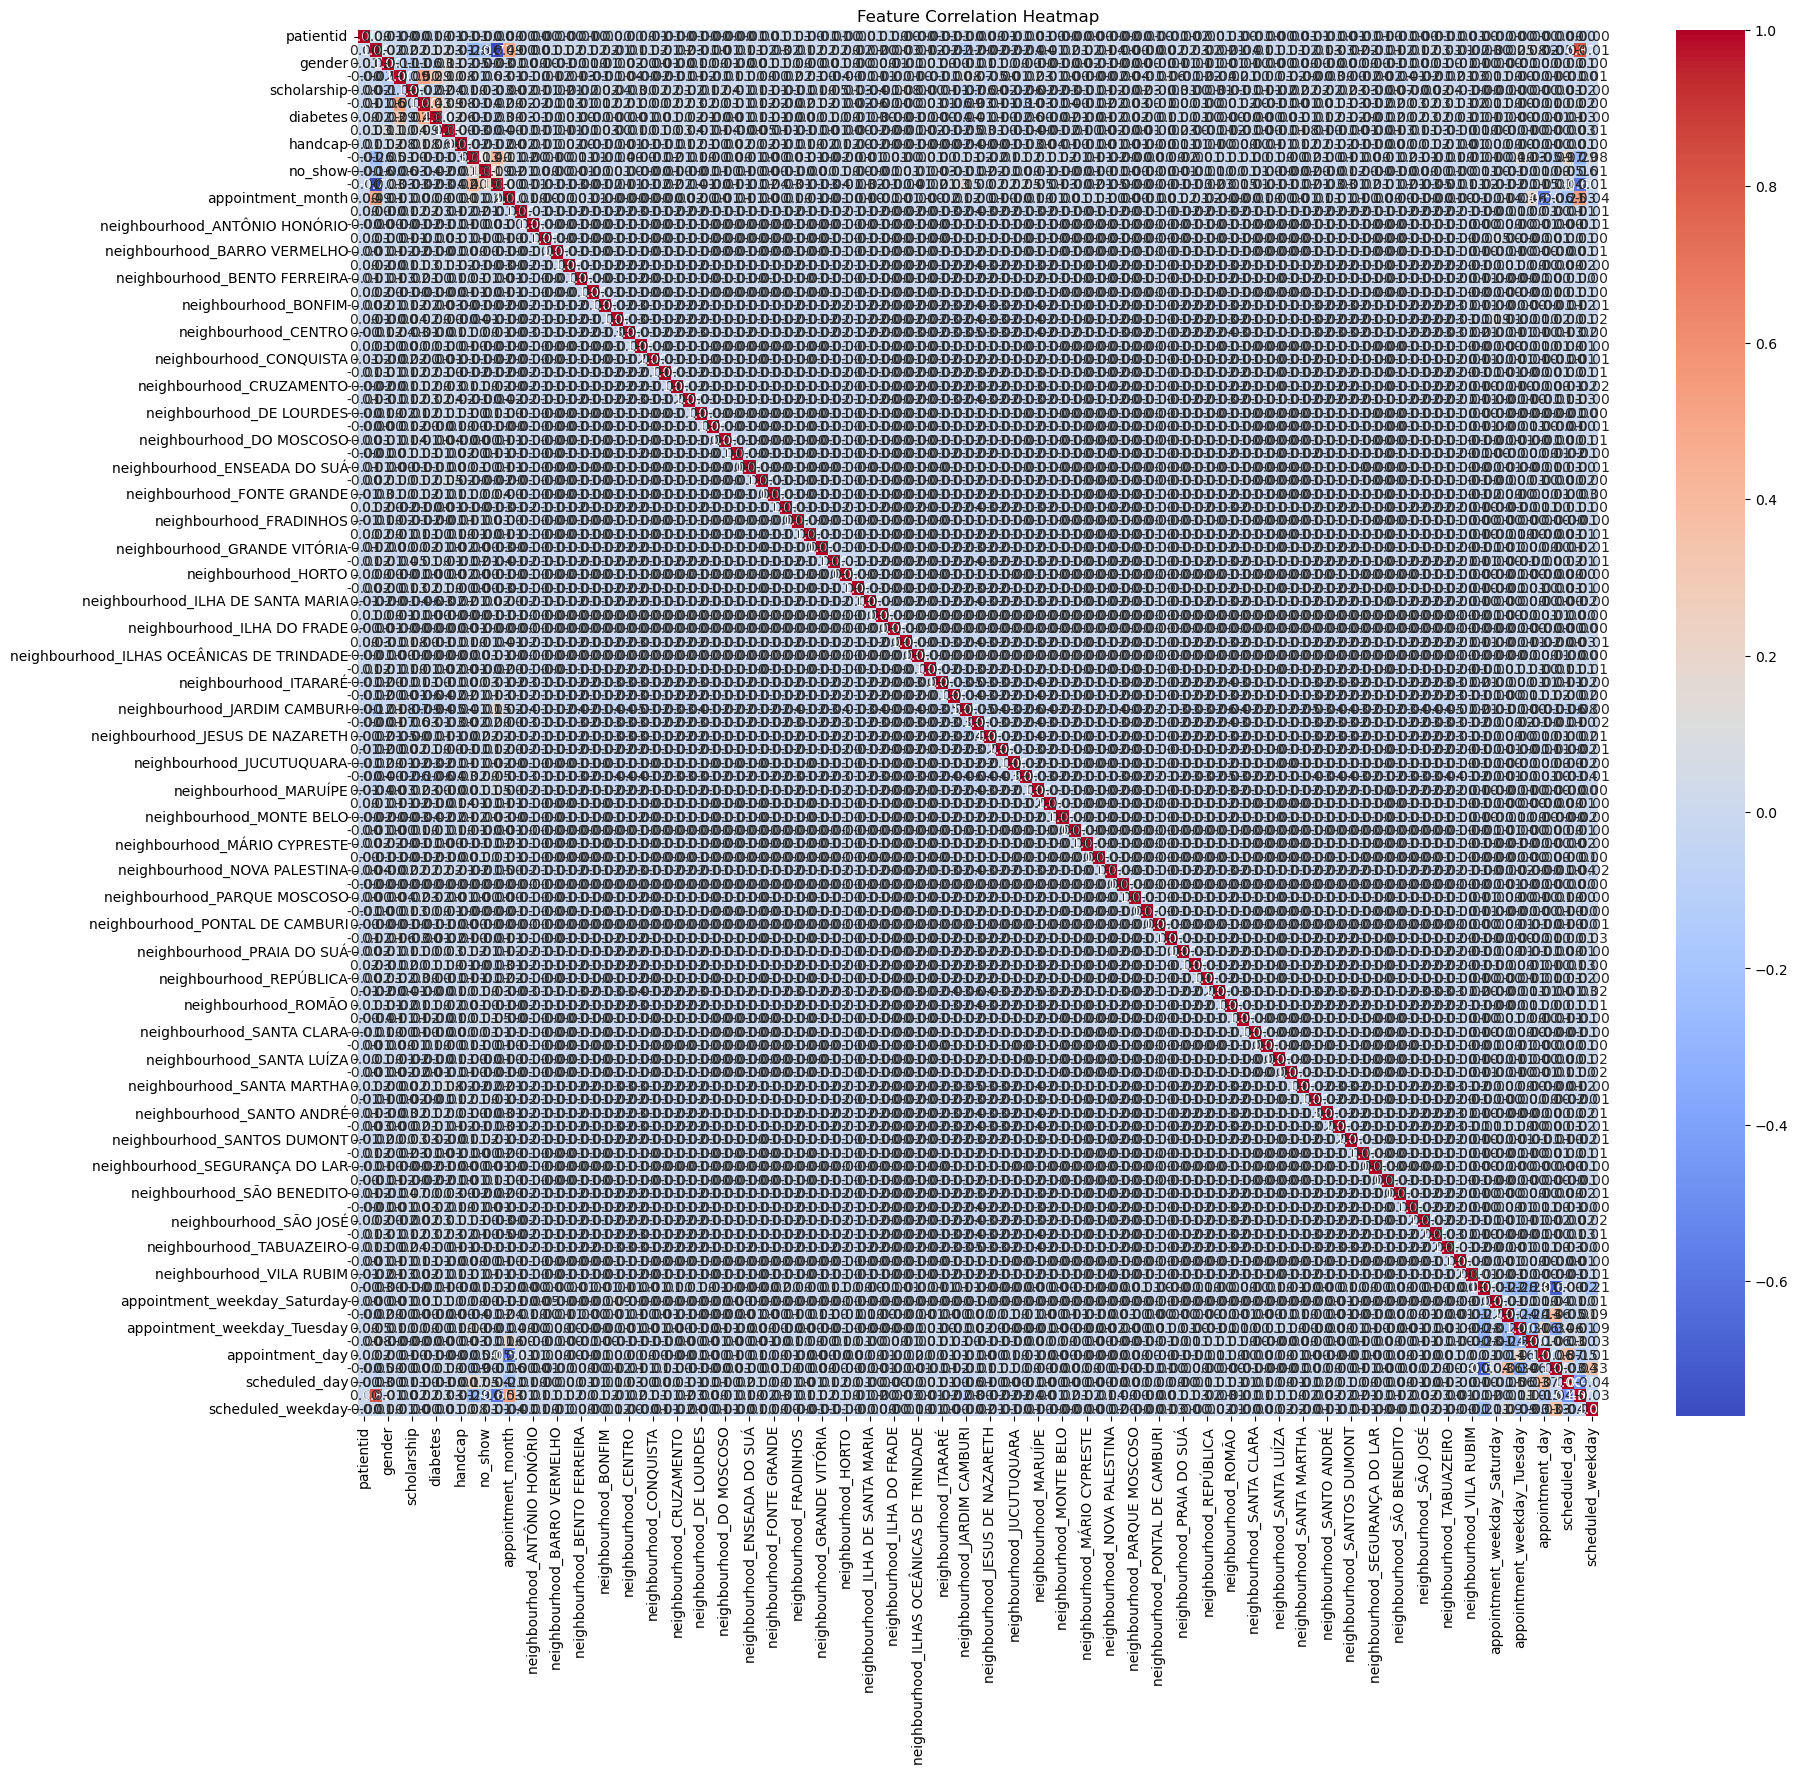

In [34]:
plt.figure(figsize=(20,18))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


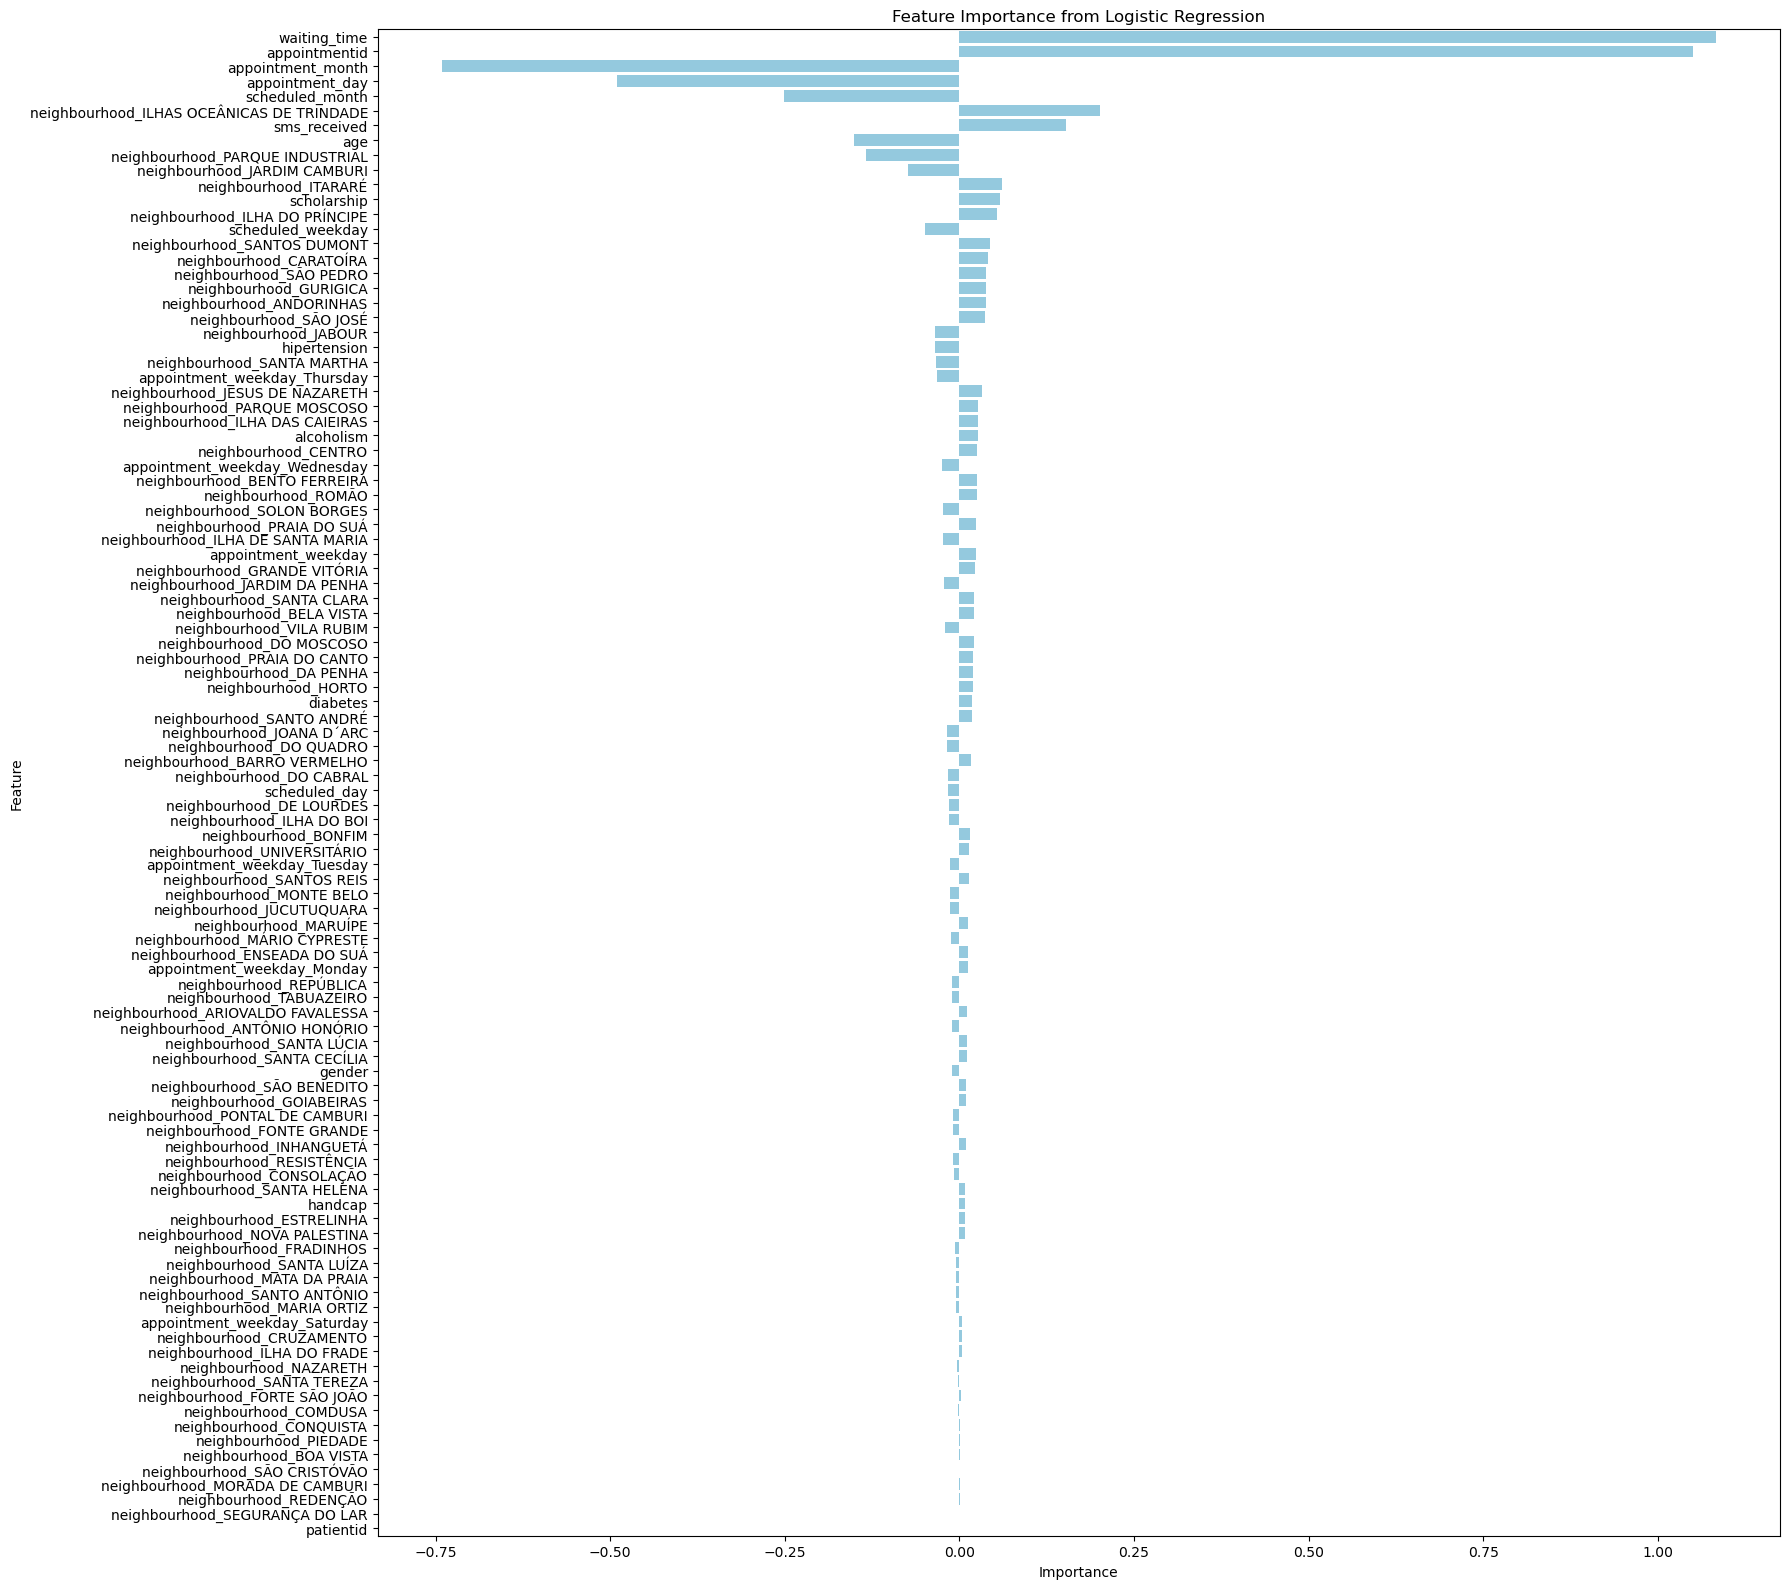

In [43]:


# 1. Make sure your model is already trained
# reg = LogisticRegression()
# reg.fit(X_train, y_train)

# 2. Extract coefficients from the logistic regression model
coefficients = reg.coef_[0]  # 1D array of weights

# 3. Match them with feature names
feat_names = X_train.columns

# 4. Create DataFrame for visualization
coef_df = pd.DataFrame({
    'Feature': feat_names,
    'Importance': coefficients
})

# 5. Sort by absolute importance (magnitude)
coef_df['Abs_Importance'] = np.abs(coef_df['Importance'])
coef_df = coef_df.sort_values(by='Abs_Importance', ascending=False)

# 6. Plot
plt.figure(figsize=(18, 16))
sns.barplot(data=coef_df, y='Feature', x='Importance', color='skyblue')
plt.title('Feature Importance from Logistic Regression')
plt.tight_layout()
plt.show()
